#  Breath Detection — Conformer + BiLSTM


In [18]:
# ── Cell 1: GPU Check ──────────────────────────────────────────
import torch
print('PyTorch :', torch.__version__)
print('GPU     :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Name    :', torch.cuda.get_device_name(0))
    print('Memory  :', round(torch.cuda.get_device_properties(0).total_memory/1e9,1), 'GB')
else:
    print(' Go to Runtime > Change runtime type > T4 GPU')

PyTorch : 2.11.0+cu128
GPU     : True
Name    : Tesla T4
Memory  : 15.6 GB


In [19]:
# ── Cell 2: Install libraries ───────────────────────────────────
!pip install -q librosa soundfile tqdm scikit-learn
print(' Libraries installed')

 Libraries installed


In [20]:
# ── Cell 3: Settings ────────────────────────────────────────────
import os

AUDIO_DIR  = '/content/drive/MyDrive/projectPG/subset_8000'
LABELS_CSV = '/content/drive/MyDrive/projectPG/labels_train_clean_100.csv'
OUTPUT_DIR = '/content/breath_model_output'

MAX_FILES  = 8000
EPOCHS     = 43
BATCH_SIZE = 32
LR         = 3e-4
VAL_SPLIT  = 0.15
SEED       = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(' Settings ready')
print(f'   MAX_FILES={MAX_FILES} | EPOCHS={EPOCHS} | LR={LR} | BATCH={BATCH_SIZE}')

 Settings ready
   MAX_FILES=8000 | EPOCHS=43 | LR=0.0003 | BATCH=32


In [21]:
# ── Cell 4: Mount Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print(' Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive mounted


In [22]:
# ── Cell 5: Load CSV + detect file structure ────────────────────
import pandas as pd

if not os.path.isfile(LABELS_CSV):
    raise FileNotFoundError(f'CSV not found: {LABELS_CSV}')
if not os.path.isdir(AUDIO_DIR):
    raise FileNotFoundError(f'Audio dir not found: {AUDIO_DIR}')

df_all = pd.read_csv(LABELS_CSV)
print(f' CSV loaded: {len(df_all):,} rows | columns: {list(df_all.columns)}')

# detect flat vs speaker/chapter structure
wav_sample = None
for root, dirs, flist in os.walk(AUDIO_DIR):
    wavs = [f for f in flist if f.endswith('.wav')]
    if wavs:
        wav_sample = os.path.join(root, wavs[0])
        break

if wav_sample is None:
    raise FileNotFoundError(f'No .wav files in {AUDIO_DIR}')

rel_depth = len(os.path.relpath(os.path.dirname(wav_sample), AUDIO_DIR).split(os.sep))
LIBRI_ROOT     = AUDIO_DIR
FLAT_STRUCTURE = (rel_depth < 2)
print(f'   Structure: {"flat" if FLAT_STRUCTURE else "speaker/chapter"}')

def build_wav_path(root, speaker, fname, flat=FLAT_STRUCTURE):
    if flat:
        return os.path.join(root, fname + '.wav')
    parts   = fname.split('_')
    chapter = parts[1] if len(parts) > 1 else parts[0]
    return os.path.join(root, speaker, chapter, fname + '.wav')

available_stems = set()
total_wav = 0
for root, dirs, flist in os.walk(LIBRI_ROOT):
    for f in flist:
        if f.endswith('.wav'):
            total_wav += 1
            available_stems.add(os.path.splitext(f)[0])
print(f'   WAV files on disk: {total_wav:,}')

df_avail = df_all[df_all['file'].astype(str).isin(available_stems)].reset_index(drop=True)
print(f'   Matched records  : {len(df_avail):,} / {len(df_all):,}')

if len(df_avail) == 0:
    raise RuntimeError('No records matched — check file names in CSV vs .wav files')

df = df_avail.sample(n=min(MAX_FILES, len(df_avail)), random_state=SEED).reset_index(drop=True)
print(f'   Using: {len(df):,} records')

 CSV loaded: 33,256 rows | columns: ['subset', 'speaker', 'file', 'breath', 'silence', 'pause', 'frame_labels', 'num_frames']
   Structure: flat
   WAV files on disk: 8,000
   Matched records  : 8,000 / 33,256
   Using: 8,000 records


In [23]:
# ── Cell 6: Quick file check ────────────────────────────────────
found = sum(
    1 for _, row in df.head(20).iterrows()
    if os.path.isfile(build_wav_path(LIBRI_ROOT, str(row['speaker']), str(row['file'])))
)
print(f'Sample check 20 files: {found} found, {20-found} missing')
print(' Ready to train!' if found >= 18 else '  Check AUDIO_DIR path')

Sample check 20 files: 20 found, 0 missing
 Ready to train!


In [24]:
# ── Cell 7: Imports + constants ─────────────────────────────────
import math, warnings, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import librosa
import soundfile as sf
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

torch.manual_seed(SEED)
np.random.seed(SEED)

SAMPLE_RATE    = 16_000
FRAME_LEN      = int(SAMPLE_RATE * 0.025)
HOP_LEN        = int(SAMPLE_RATE * 0.010)
HOP_LEN_SEC    = 0.010
N_MELS         = 64
MODEL_DIM      = 128
NUM_HEADS      = 4
NUM_CONFORMERS = 3
NUM_BILSTM     = 1
DROPOUT        = 0.2
FEAT_DIM       = N_MELS + 2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Constants ready | Device: {DEVICE}')
print(f'   NUM_CONFORMERS={NUM_CONFORMERS} | NUM_BILSTM={NUM_BILSTM} | DROPOUT={DROPOUT}')

 Constants ready | Device: cuda
   NUM_CONFORMERS=3 | NUM_BILSTM=1 | DROPOUT=0.2


In [25]:
# ── Cell 8: Feature extraction ──────────────────────────────────
def extract_features(waveform, sr=SAMPLE_RATE):
    if sr != SAMPLE_RATE:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=SAMPLE_RATE)
    mel    = librosa.feature.melspectrogram(
        y=waveform, sr=SAMPLE_RATE,
        n_fft=FRAME_LEN, hop_length=HOP_LEN,
        win_length=FRAME_LEN, n_mels=N_MELS, power=2.0
    )
    mel_db = librosa.power_to_db(mel + 1e-9, ref=1.0).T
    zcr    = librosa.feature.zero_crossing_rate(
        waveform, frame_length=FRAME_LEN, hop_length=HOP_LEN
    ).T
    vms    = np.var(mel_db, axis=1, keepdims=True)
    T      = min(mel_db.shape[0], zcr.shape[0], vms.shape[0])
    return np.concatenate([mel_db[:T], zcr[:T], vms[:T]], axis=1).astype(np.float32)

def normalize_features(features):
    mean = features.mean(axis=0, keepdims=True)
    std  = features.std(axis=0,  keepdims=True) + 1e-8
    return (features - mean) / std

print(' Feature extraction ready')

 Feature extraction ready


In [26]:
# ── Cell 9: Dataset ─────────────────────────────────────────────
class BreathDataset(Dataset):
    def __init__(self, records, libri_root, max_duration_sec=30):
        self.samples    = []
        self.max_frames = int(max_duration_sec / HOP_LEN_SEC)
        skipped = 0
        for _, row in tqdm(records.iterrows(), total=len(records), desc='Loading'):
            speaker   = str(row['speaker'])
            fname     = str(row['file'])
            label_str = str(row['frame_labels'])
            wav_path  = build_wav_path(libri_root, speaker, fname)
            if not os.path.isfile(wav_path):
                skipped += 1; continue
            labels = np.array([int(c) for c in label_str if c in '01'], dtype=np.float32)
            if labels.size == 0:
                skipped += 1; continue
            try:
                waveform, sr = sf.read(wav_path, dtype='float32')
                if waveform.ndim > 1:
                    waveform = waveform.mean(axis=1)
            except Exception:
                skipped += 1; continue
            features = normalize_features(extract_features(waveform, sr))
            T = min(features.shape[0], labels.shape[0], self.max_frames)
            self.samples.append((features[:T], labels[:T]))
        print(f'Loaded {len(self.samples)} | skipped {skipped}')

    def __len__(self):  return len(self.samples)
    def __getitem__(self, idx):
        f, l = self.samples[idx]
        return torch.from_numpy(f), torch.from_numpy(l)


def collate_fn(batch):
    feats, labs = zip(*batch)
    max_T    = max(f.shape[0] for f in feats)
    feat_dim = feats[0].shape[1]
    feat_pad = torch.zeros(len(feats), max_T, feat_dim)
    lab_pad  = torch.zeros(len(feats), max_T)
    mask     = torch.zeros(len(feats), max_T, dtype=torch.bool)
    for i, (f, l) in enumerate(zip(feats, labs)):
        T = f.shape[0]
        feat_pad[i, :T] = f
        lab_pad[i,  :T] = l
        mask[i,     :T] = True
    return feat_pad, lab_pad, mask

print(' Dataset ready')

 Dataset ready


In [27]:
# ── Cell 10: Model architecture ─────────────────────────────────
class ConvolutionModule(nn.Module):
    def __init__(self, channels, kernel_size=31):
        super().__init__()
        self.ln  = nn.LayerNorm(channels)
        self.pw1 = nn.Conv1d(channels, 2*channels, 1)
        self.glu = nn.GLU(dim=1)
        self.dw  = nn.Conv1d(channels, channels, kernel_size,
                             padding=kernel_size//2, groups=channels)
        self.bn  = nn.BatchNorm1d(channels)
        self.act = nn.SiLU()
        self.pw2 = nn.Conv1d(channels, channels, 1)
        self.drop= nn.Dropout(DROPOUT)

    def forward(self, x):
        r = x
        x = self.ln(x).transpose(1,2)
        x = self.glu(self.pw1(x))
        x = self.act(self.bn(self.dw(x)))
        x = self.drop(self.pw2(x)).transpose(1,2)
        return x + r


class FeedForwardModule(nn.Module):
    def __init__(self, dim, expansion=4):
        super().__init__()
        self.ln  = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, dim*expansion)
        self.act = nn.SiLU()
        self.d1  = nn.Dropout(DROPOUT)
        self.fc2 = nn.Linear(dim*expansion, dim)
        self.d2  = nn.Dropout(DROPOUT)

    def forward(self, x):
        return x + 0.5*self.d2(self.fc2(self.d1(self.act(self.fc1(self.ln(x))))))


class ConformerBlock(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.ff1    = FeedForwardModule(dim)
        self.ln     = nn.LayerNorm(dim)
        self.attn   = nn.MultiheadAttention(dim, num_heads, dropout=DROPOUT, batch_first=True)
        self.drop   = nn.Dropout(DROPOUT)
        self.conv   = ConvolutionModule(dim)
        self.ff2    = FeedForwardModule(dim)
        self.ln_out = nn.LayerNorm(dim)

    def forward(self, x, key_padding_mask=None):
        x = self.ff1(x)
        r = x
        x_ln = self.ln(x)
        x, _ = self.attn(x_ln, x_ln, x_ln, key_padding_mask=key_padding_mask)
        x = self.conv(self.ff2(self.ln_out(r + self.drop(x))))
        return x


class ConformerBiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.subsample = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1), nn.ReLU()
        )
        sub_feat = 32 * math.ceil(math.ceil(FEAT_DIM/2)/2)
        self.proj       = nn.Linear(sub_feat, MODEL_DIM)
        self.drop       = nn.Dropout(DROPOUT)
        self.conformers = nn.ModuleList([
            ConformerBlock(MODEL_DIM, NUM_HEADS)
            for _ in range(NUM_CONFORMERS)
        ])
        self.upsample = nn.Sequential(
            nn.ConvTranspose1d(MODEL_DIM, MODEL_DIM, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose1d(MODEL_DIM, MODEL_DIM, 4, stride=2, padding=1), nn.ReLU()
        )
        self.bilstm = nn.LSTM(
            MODEL_DIM, MODEL_DIM//2,
            num_layers=NUM_BILSTM,
            batch_first=True, bidirectional=True,
            dropout=DROPOUT if NUM_BILSTM > 1 else 0.0
        )
        self.classifier = nn.Sequential(
            nn.LayerNorm(MODEL_DIM),
            nn.Linear(MODEL_DIM, 1)
        )

    def forward(self, x, mask=None):
        B, T, F = x.shape
        x_2d = self.subsample(x.unsqueeze(1))
        B2, C2, T2, F2 = x_2d.shape
        x_flat = self.drop(self.proj(
            x_2d.permute(0,2,1,3).contiguous().view(B2, T2, C2*F2)
        ))
        pad_mask = (~mask[:, ::4][:, :T2]) if mask is not None else None
        for blk in self.conformers:
            x_flat = blk(x_flat, key_padding_mask=pad_mask)
        x_up = self.upsample(x_flat.transpose(1,2)).transpose(1,2)
        T_up = x_up.shape[1]
        if T_up >= T:
            x_up = x_up[:, :T, :]
        else:
            pad = torch.zeros(B, T-T_up, x_up.shape[2], device=x_up.device)
            x_up = torch.cat([x_up, pad], dim=1)
        x_lstm, _ = self.bilstm(x_up)
        return self.classifier(x_lstm).squeeze(-1)  # (B, T) logits


model = ConformerBiLSTM().to(DEVICE)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f' Model ready — {total:,} parameters')

 Model ready — 1,464,289 parameters


In [28]:
# ── Cell 11: Prepare data ───────────────────────────────────────
train_df, val_df = train_test_split(df, test_size=VAL_SPLIT, random_state=SEED)
print(f'Train: {len(train_df)} | Val: {len(val_df)}')

train_ds = BreathDataset(train_df, LIBRI_ROOT)
val_ds   = BreathDataset(val_df,   LIBRI_ROOT)

if len(train_ds) == 0:
    raise RuntimeError('No files loaded — check paths')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f'\n Loaders ready | Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train: 6800 | Val: 1200


Loading:   0%|          | 0/6800 [00:00<?, ?it/s]

Loaded 6800 | skipped 0


Loading:   0%|          | 0/1200 [00:00<?, ?it/s]

Loaded 1200 | skipped 0

 Loaders ready | Train batches: 213 | Val batches: 38


In [29]:
# ── Cell 12: Training setup ─────────────────────────────────────
def compute_metrics(preds, targets, threshold=0.5):
    p = (preds >= threshold).astype(int)
    t = targets.astype(int)

    return {
        'accuracy': accuracy_score(t, p),
        'precision': precision_score(t, p, zero_division=0),
        'recall': recall_score(t, p, zero_division=0),
        'f1': f1_score(t, p, zero_division=0)
    }

def evaluate_thresholds(preds, targets):
    thresholds = [0.30, 0.35, 0.40, 0.45,
                  0.50, 0.55, 0.60, 0.65, 0.70]

    print("="*72)
    print(f"{'Threshold':<10} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")
    print("="*72)

    best_f1 = 0
    best_thr = 0.5

    for thr in thresholds:
        m = compute_metrics(preds, targets, threshold=thr)

        print(f"{thr:<10.2f} "
              f"{m['accuracy']:<10.4f} "
              f"{m['precision']:<10.4f} "
              f"{m['recall']:<10.4f} "
              f"{m['f1']:<10.4f}")

        if m['f1'] > best_f1:
            best_f1 = m['f1']
            best_thr = thr

    print("="*72)
    print(f"Best Threshold = {best_thr:.2f}")
    print(f"Best F1        = {best_f1:.4f}")


def run_epoch(model, loader, optimizer, criterion, training=True):
    model.train() if training else model.eval()
    total_loss, all_p, all_t = 0.0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for feat, lab, mask in loader:
            feat, lab, mask = feat.to(DEVICE), lab.to(DEVICE), mask.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(feat, mask)
            valid  = mask.view(-1)
            loss   = criterion(logits.view(-1)[valid], lab.view(-1)[valid])
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 2.0)
                optimizer.step()
            total_loss += loss.item()
            with torch.no_grad():
                all_p.append(torch.sigmoid(logits).view(-1)[valid].cpu().numpy())
                all_t.append(lab.view(-1)[valid].cpu().numpy())
    return total_loss / max(len(loader), 1), \
           compute_metrics(np.concatenate(all_p), np.concatenate(all_t))


POS_WEIGHT = 6.0
criterion  = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT]).to(DEVICE))
optimizer  = optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-2)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

print(f' Training setup ready')
print(f'   pos_weight={POS_WEIGHT} | weight_decay=5e-2 | grad_clip=2.0')

 Training setup ready
   pos_weight=6.0 | weight_decay=5e-2 | grad_clip=2.0


In [30]:
# ── Cell 13: Training loop ──────────────────────────────────────
PATIENCE          = 8
epochs_no_improve = 0
best_f1           = 0.0
best_path         = os.path.join(OUTPUT_DIR, 'breath_model_best.pt')
log_rows          = []

print('=' * 68)
print(f'Epochs={EPOCHS} | Patience={PATIENCE} | Train={len(train_ds)} | Val={len(val_ds)}')
print(f'pos_weight={POS_WEIGHT} | LR={LR} | dropout={DROPOUT}')
print('=' * 68)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_m = run_epoch(model, train_loader, optimizer, criterion, training=True)
    vl_loss, vl_m = run_epoch(model, val_loader,   optimizer, criterion, training=False)
    scheduler.step()
    elapsed = time.time() - t0

    log_rows.append({
        'epoch': epoch, 'train_loss': tr_loss, 'val_loss': vl_loss,
        **{f'train_{k}': v for k, v in tr_m.items()},
        **{f'val_{k}':   v for k, v in vl_m.items()}
    })

    star = ''
    if vl_m['f1'] > best_f1:
        best_f1 = vl_m['f1']
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'feat_dim': FEAT_DIM, 'model_dim': MODEL_DIM,
            'num_heads': NUM_HEADS,
            'num_conformers': NUM_CONFORMERS,
            'num_bilstm': NUM_BILSTM,
            'dropout': DROPOUT,
            'val_metrics': vl_m
        }, best_path)
        star = '  ★ saved'
    else:
        epochs_no_improve += 1

    print(f'Ep {epoch:3d}/{EPOCHS} | '
          f'L {tr_loss:.4f}/{vl_loss:.4f} | '
          f'Acc {vl_m["accuracy"]:.3f} | '
          f'Prec {vl_m["precision"]:.3f} | '
          f'Rec {vl_m["recall"]:.3f} | '
          f'F1 {vl_m["f1"]:.3f} | '
          f'{elapsed:.0f}s{star}')


print('\n' + '='*68)
print(f' DONE | Best Val F1: {best_f1:.4f}')


Epochs=43 | Patience=8 | Train=6800 | Val=1200
pos_weight=6.0 | LR=0.0003 | dropout=0.2
Ep   1/43 | L 0.2527/0.2127 | Acc 0.957 | Prec 0.411 | Rec 0.755 | F1 0.532 | 41s  ★ saved
Ep   2/43 | L 0.1837/0.2002 | Acc 0.955 | Prec 0.407 | Rec 0.832 | F1 0.547 | 40s  ★ saved
Ep   3/43 | L 0.1627/0.1942 | Acc 0.971 | Prec 0.548 | Rec 0.721 | F1 0.622 | 40s  ★ saved
Ep   4/43 | L 0.1474/0.1583 | Acc 0.968 | Prec 0.511 | Rec 0.814 | F1 0.628 | 40s  ★ saved
Ep   5/43 | L 0.1373/0.1620 | Acc 0.966 | Prec 0.484 | Rec 0.845 | F1 0.616 | 40s
Ep   6/43 | L 0.1275/0.1510 | Acc 0.967 | Prec 0.495 | Rec 0.862 | F1 0.629 | 40s  ★ saved
Ep   7/43 | L 0.1238/0.1459 | Acc 0.966 | Prec 0.486 | Rec 0.843 | F1 0.617 | 40s
Ep   8/43 | L 0.1168/0.1494 | Acc 0.964 | Prec 0.474 | Rec 0.862 | F1 0.612 | 40s
Ep   9/43 | L 0.1125/0.1500 | Acc 0.961 | Prec 0.451 | Rec 0.881 | F1 0.597 | 40s
Ep  10/43 | L 0.1061/0.1485 | Acc 0.963 | Prec 0.467 | Rec 0.888 | F1 0.612 | 40s
Ep  11/43 | L 0.1027/0.1552 | Acc 0.952 | Prec 

In [31]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

checkpoint = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

all_probs = []
all_targets = []

with torch.no_grad():
    for feat, lab, mask in val_loader:
        feat = feat.to(DEVICE)
        lab = lab.to(DEVICE)
        mask = mask.to(DEVICE)

        logits = model(feat, mask)
        probs = torch.sigmoid(logits)

        valid = mask.view(-1)

        all_probs.extend(probs.view(-1)[valid].cpu().numpy())
        all_targets.extend(lab.view(-1)[valid].cpu().numpy())

all_probs = np.array(all_probs)
all_targets = np.array(all_targets)

thresholds = np.arange(0.30, 0.71, 0.05)

best_f1 = 0
best_threshold = 0

print("=" * 72)
print(f"{'Threshold':<12}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1':<12}")
print("=" * 72)

for th in thresholds:

    preds = (all_probs >= th).astype(int)

    acc = accuracy_score(all_targets, preds)
    prec = precision_score(all_targets, preds, zero_division=0)
    rec = recall_score(all_targets, preds, zero_division=0)
    f1 = f1_score(all_targets, preds, zero_division=0)

    print(f"{th:<12.2f}{acc:<12.4f}{prec:<12.4f}{rec:<12.4f}{f1:<12.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = th

print("=" * 72)
print(f" Best Threshold = {best_threshold:.2f}")
print(f" Best F1        = {best_f1:.4f}")

Threshold   Accuracy    Precision   Recall      F1          
0.30        0.9748      0.5846      0.7861      0.6705      
0.35        0.9753      0.5929      0.7787      0.6732      
0.40        0.9759      0.6019      0.7717      0.6763      
0.45        0.9763      0.6092      0.7650      0.6783      
0.50        0.9767      0.6169      0.7581      0.6803      
0.55        0.9772      0.6251      0.7515      0.6825      
0.60        0.9776      0.6341      0.7437      0.6845      
0.65        0.9781      0.6441      0.7350      0.6866      
0.70        0.9785      0.6545      0.7242      0.6876      
 Best Threshold = 0.70
 Best F1        = 0.6876


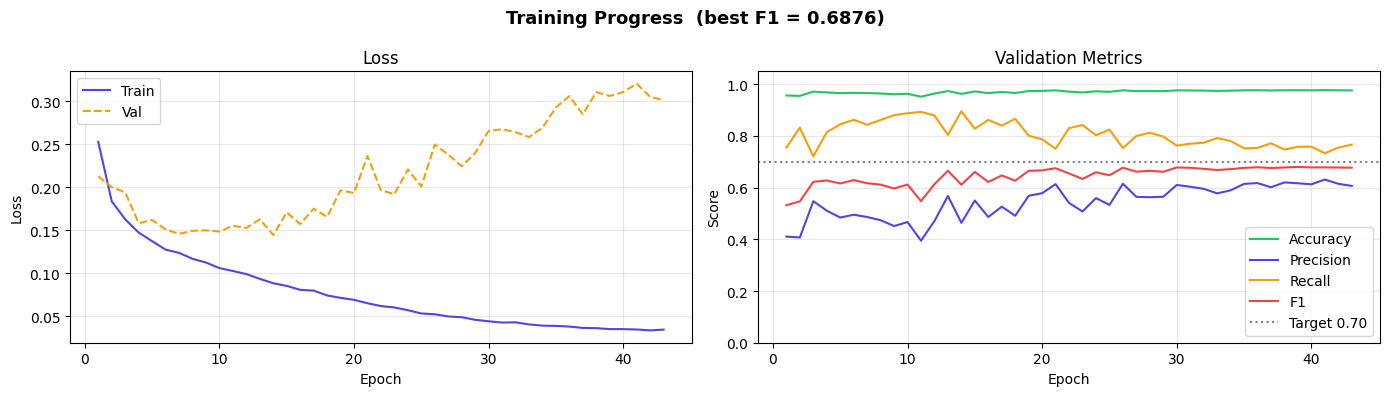

 Saved: training_log.csv | training_curves.png


In [32]:
# ── Cell 14: Training curves ────────────────────────────────────
import matplotlib.pyplot as plt

log_df = pd.DataFrame(log_rows)
log_df.to_csv(os.path.join(OUTPUT_DIR, 'training_log.csv'), index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Training Progress  (best F1 = {best_f1:.4f})', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(log_df['epoch'], log_df['train_loss'], label='Train', color='#4f46e5')
ax.plot(log_df['epoch'], log_df['val_loss'],   label='Val',   color='#f59e0b', ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for col, color, label in [
    ('val_accuracy',  '#22c55e', 'Accuracy'),
    ('val_precision', '#4f46e5', 'Precision'),
    ('val_recall',    '#f59e0b', 'Recall'),
    ('val_f1',        '#ef4444', 'F1'),
]:
    ax.plot(log_df['epoch'], log_df[col], label=label, color=color)
ax.axhline(0.70, color='gray', ls=':', lw=1.5, label='Target 0.70')
ax.set_xlabel('Epoch'); ax.set_ylabel('Score'); ax.set_title('Validation Metrics')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3); ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print(' Saved: training_log.csv | training_curves.png')

In [33]:
# ── Cell 15: Download model ─────────────────────────────────────
from google.colab import files
size_mb = os.path.getsize(best_path) / 1e6
print(f' breath_model_best.pt  ({size_mb:.1f} MB)')
files.download(best_path)

 breath_model_best.pt  (5.9 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
# ── Cell 16: Save to Google Drive (optional) ────────────────────
import shutil
drive_save = '/content/drive/MyDrive/projectPG/3breath_model_best.pt'
shutil.copy(best_path, drive_save)
print(f' Saved to Drive: {drive_save}')

 Saved to Drive: /content/drive/MyDrive/projectPG/3breath_model_best.pt


# **________________________________________________________________________________**